## Problem 2: GPS Space Segment [14 points]
**Goal of this problem:** Students will learn about the GPS space segment, GNSS orbits, and the effect on receivers at different latitudes.
Students will also get exposure to the open-source GNSS Python Library (`gnss-lib-py`) developed and maintained by the NAV Lab here at Stanford.
The GNSS Python Library is registered in the Python package index (https://pypi.org/project/gnss-lib-py/).
So, you can install it by simply typing the following in the first cell:
```
%pip install gnss-lib-py
```

If you are *new to Google Colab*, please start this early and ask any questions so that we can resolve any issues before the due date.

Behind the scenes in this problem, we are querying the IGS (see problem 1) precise ephemeris data.
This post-processed data (roughly weekly) contains the control segment's "best" estimates of the satellite positions.
IGS compiles estimates for multiple navigation satellite constellations.
You will notice the following: GPS (US), GLONASS (Russia), Galileo (EU), and Beidou (China).
But, there is also one regional navigation satellite system in this problem: QZSS.
This is the "Quasi-Zenith Satellite System" from JAXA in Japan.
Unfortunately, this problem does not include IRNSS (Indian Regional Navigation Satellite System), also known as NavIC (Navigation with Indian Constellation).
See more at https://www.gps.gov/systems/gnss/.

Lastly, in this problem, we are making skyplots.
This is a term in the GPS/GNSS community referring to a hemisphere representation of which satellites you would see (i.e., which satellites you will get a signal from and which direction the signal would come from).

*Figure: Skyplot (left) and corresponding geometric interpretation (right)*

In [20]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


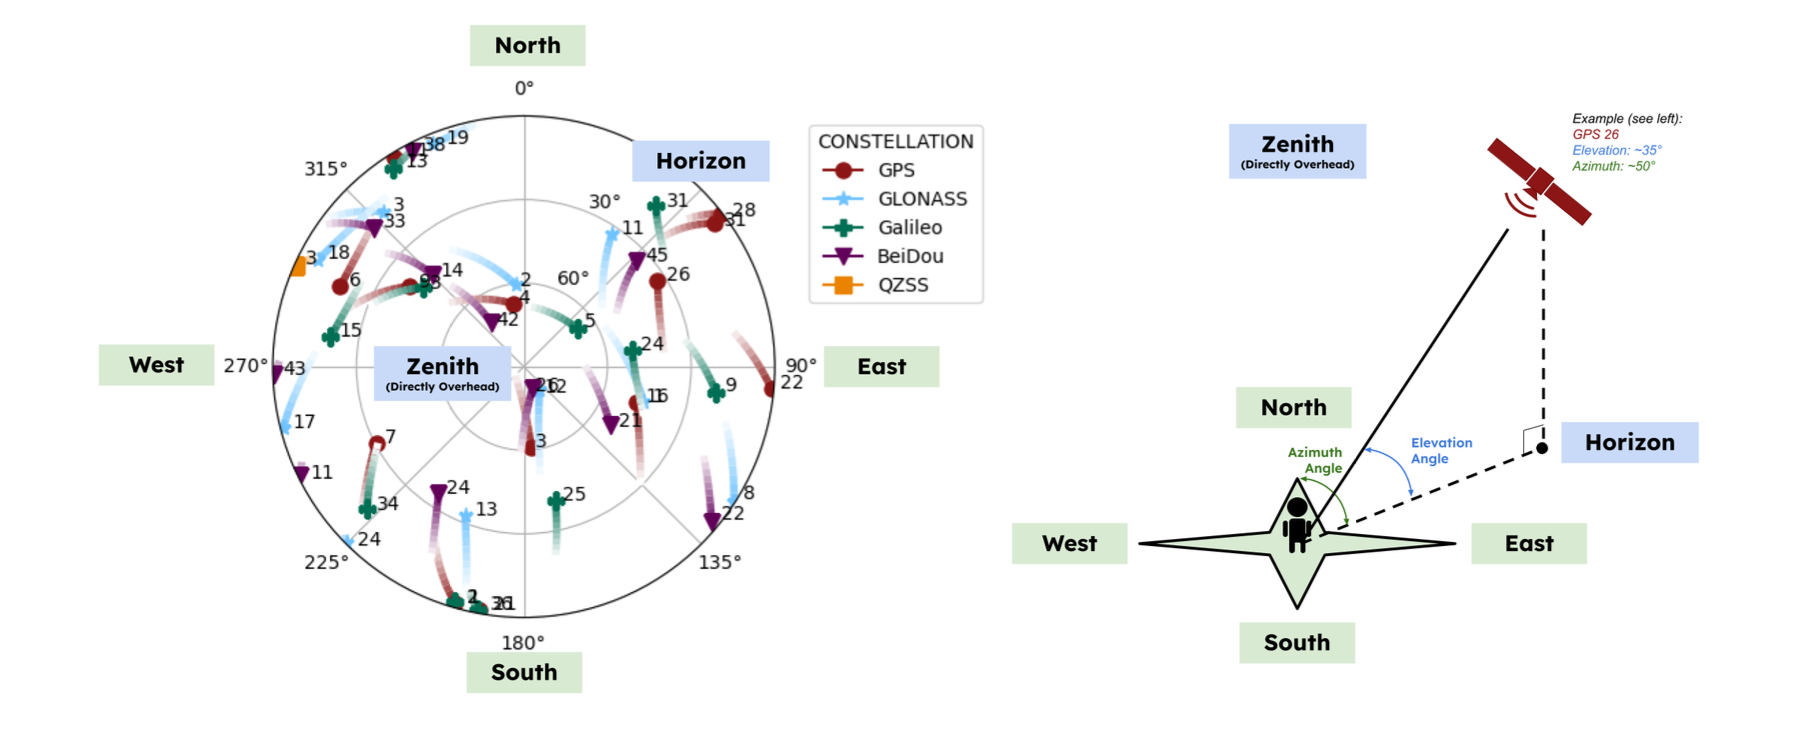

In [21]:
from IPython.display import Image, display

display(Image(filename="/content/drive/MyDrive/AA 272 - GPS Class/HW1/figures/SkyplotUnderstanding.png", width=800))

### 2.1 [2 points]

Follow the tutorial at https://gnss-lib-py.readthedocs.io/en/latest/tutorials/utils/tutorials_ephemeris_downloader_notebook.html.
Include the skyplot showing the satellite elevation and azimuth over one hour.

*Hint:* This plot should exactly match the tutorial.

**Note:** For the rest of this problem, please feel free to use the same code as from the tutorial, but change the input latitude, longitude, altitude, start time, and end time.

***ANSWER***

In [22]:
%pip install gnss-lib-py > /dev/null

In [23]:
import numpy as np
import gnss_lib_py as glp
from datetime import datetime, timezone, timedelta
from zoneinfo import ZoneInfo
from pytz import all_timezones

In [24]:
def plot_gps(lat, lon, alt, timestamp_start, timestamp_end, *, where_key_idx = None, where_value = None):
  gps_millis = glp.datetime_to_gps_millis(np.array([timestamp_start,timestamp_end]))
  sp3_path = glp.load_ephemeris(file_type="sp3",
                                gps_millis=gps_millis,
                                verbose=True)

  sp3 = glp.Sp3(sp3_path)

  # create receiver state NavData instance to pass into skyplot function
  x_rx_m, y_rx_m, z_rx_m = glp.geodetic_to_ecef(np.array([[lat,lon,alt]]))[0]
  receiver_state = glp.NavData()
  receiver_state["gps_millis"] = glp.datetime_to_gps_millis(timestamp_start)
  receiver_state["x_rx_m"] = x_rx_m
  receiver_state["y_rx_m"] = y_rx_m
  receiver_state["z_rx_m"] = z_rx_m

  cropped_sp3 = sp3.where("gps_millis",gps_millis[0],"geq").where("gps_millis",gps_millis[1],"leq")

  if where_key_idx is not None and where_value is not None:
    cropped_sp3 = cropped_sp3.where(where_key_idx, where_value)

  fig = glp.plot_skyplot(cropped_sp3,receiver_state)

In [25]:
lat, lon, alt = 37.42984154652992, -122.16946303566934, 0.
timestamp_start = datetime(year=2023, month=3, day=14, hour=12, tzinfo=timezone.utc)
timestamp_end = datetime(year=2023, month=3, day=14, hour=13, tzinfo=timezone.utc)

ephemeris dates needed: [datetime.date(2023, 3, 14)]
using previously downloaded file:
 /content/data/ephemeris/sp3/COD0MGXFIN_20230730000_01D_05M_ORB.SP3
using previously downloaded file:
 /content/data/ephemeris/sp3/COD0MGXFIN_20230730000_01D_05M_ORB.SP3


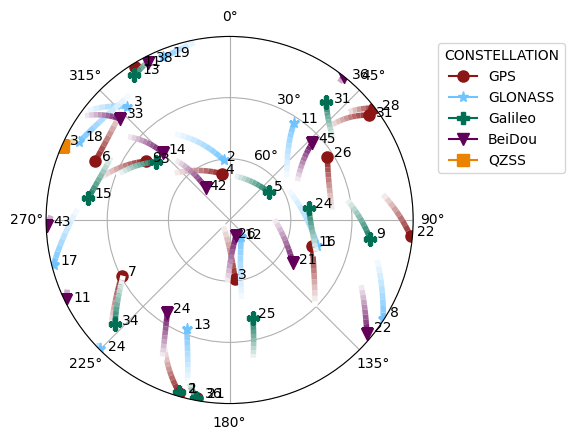

In [26]:
plot_gps(lat, lon, alt, timestamp_start, timestamp_end)


[Replace with your answer]

### 2.2 [2 Point]

Use the latitude, longitude, and height above the ellipsoid (called altitude in the code) of the SLAC station from problem 1.1.
Feel free to use Wolfram Alpha or another online conversion tool to get the coordinates in decimal form.
Use 9 am - 10 am Pacific Time on September 22, 2025 as the query time (the first day of this quarter).

*Hint:* Note that longitude at SLAC is *negative* since we are *West* of the prime meridian.

***ANSWER***

In [27]:
slac_lat = 37 + 24/60 + 59.46807/3600
slac_lon = -122 - 12/60 - 15.36454/3600
slac_alt = 63.667 # m

slac_timestamp_start = datetime(2025, 9, 22, 9, tzinfo=ZoneInfo("America/Los_Angeles"))
slac_timestamp_end = datetime(2025, 9, 22, 10, tzinfo=ZoneInfo("America/Los_Angeles"))

print(f"Start: {slac_timestamp_start}")
print(f"End:   {slac_timestamp_end}")

Start: 2025-09-22 09:00:00-07:00
End:   2025-09-22 10:00:00-07:00


ephemeris dates needed: [datetime.date(2025, 9, 22)]
using previously downloaded file:
 /content/data/ephemeris/sp3/GFZ0MGXRAP_20252650000_01D_05M_ORB.SP3
using previously downloaded file:
 /content/data/ephemeris/sp3/GFZ0MGXRAP_20252650000_01D_05M_ORB.SP3


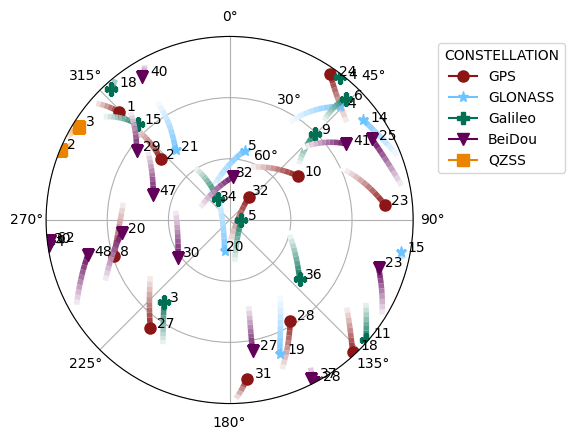

In [28]:
plot_gps(slac_lat, slac_lon, slac_alt, slac_timestamp_start, slac_timestamp_end)

### 2.3 [2 Points]

Repeat 2.2, but isolate only the GPS satellites.

*Hint:* Type `cropped_sp3` in a new cell and run the result. Which column of the data designates the satellite constellation? Also refer to the documentation: https://gnss-lib-py.readthedocs.io/en/latest/reference/navdata/navdata.html#navdata.NavData.where

***ANSWER***


ephemeris dates needed: [datetime.date(2025, 9, 22)]
using previously downloaded file:
 /content/data/ephemeris/sp3/GFZ0MGXRAP_20252650000_01D_05M_ORB.SP3
using previously downloaded file:
 /content/data/ephemeris/sp3/GFZ0MGXRAP_20252650000_01D_05M_ORB.SP3


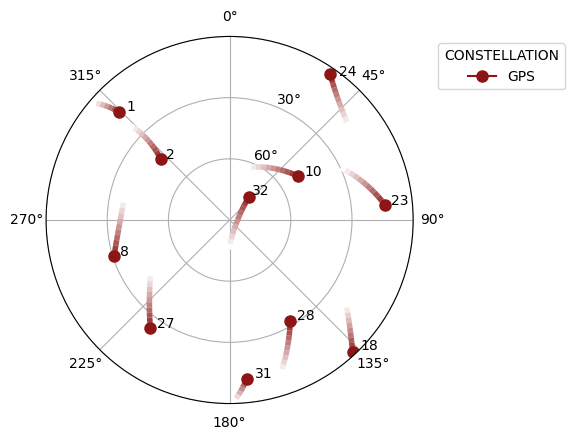

In [29]:
plot_gps(slac_lat, slac_lon, slac_alt, slac_timestamp_start, slac_timestamp_end,
         where_key_idx = "gnss_id",
         where_value = "gps")

### 2.4 [8 points]

Produce the skyplots for a 24-hour segment (e.g., midnight to midnight) at the following locations and times.
Use all the satellite constellations from IGS and use an altitude of zero, if needed.
Then, comment on the differences between them and why these differences occur.

1. The North Pole on December 25, 2024 in UTC. Please use true north (i.e., latitude of 90° and longitude of 0°) rather than magnetic north.
2. Singapore on March 20, 2025 (i.e., the vernal equinox Singapore Time)
3. Tokyo on July 23, 2021 (i.e., the opening ceremony day for the 2020 Summer Olympics (it was held in 2021))
4. Rio de Janeiro on August 5, 2016 (i.e., the opening ceremony day for the 2016 Summer Olympics)

*Just for fun, there is an interesting connection between the QZSS orbits and the sun. Check out the Analemma Wikipedia page for more.*

***ANSWER***

ephemeris dates needed: [datetime.date(2024, 12, 24), datetime.date(2024, 12, 25), datetime.date(2024, 12, 26)]
using previously downloaded file:
 /content/data/ephemeris/sp3/COD0MGXFIN_20243590000_01D_05M_ORB.SP3
using previously downloaded file:
 /content/data/ephemeris/sp3/COD0MGXFIN_20243600000_01D_05M_ORB.SP3
using previously downloaded file:
 /content/data/ephemeris/sp3/COD0MGXFIN_20243610000_01D_05M_ORB.SP3
using previously downloaded file:
 /content/data/ephemeris/sp3/COD0MGXFIN_20243590000_01D_05M_ORB.SP3
using previously downloaded file:
 /content/data/ephemeris/sp3/COD0MGXFIN_20243600000_01D_05M_ORB.SP3
using previously downloaded file:
 /content/data/ephemeris/sp3/COD0MGXFIN_20243610000_01D_05M_ORB.SP3
North Pole on December 25, 2024


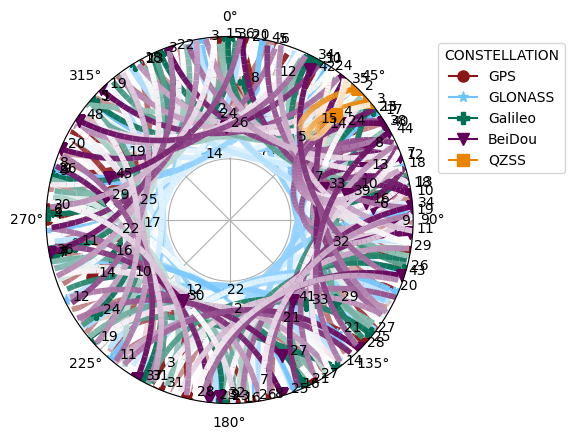

In [30]:
plot_gps(
    lat = 90,
    lon = 0,
    alt = 0,
    timestamp_start = datetime(2024, 12, 25, tzinfo=timezone.utc),
    timestamp_end = datetime(2024, 12, 26, tzinfo=timezone.utc))
print("North Pole on December 25, 2024")

ephemeris dates needed: [datetime.date(2025, 3, 19), datetime.date(2025, 3, 20)]
using previously downloaded file:
 /content/data/ephemeris/sp3/COD0MGXFIN_20250780000_01D_05M_ORB.SP3
using previously downloaded file:
 /content/data/ephemeris/sp3/COD0MGXFIN_20250790000_01D_05M_ORB.SP3
using previously downloaded file:
 /content/data/ephemeris/sp3/COD0MGXFIN_20250780000_01D_05M_ORB.SP3
using previously downloaded file:
 /content/data/ephemeris/sp3/COD0MGXFIN_20250790000_01D_05M_ORB.SP3
Singapore on March 20, 2025


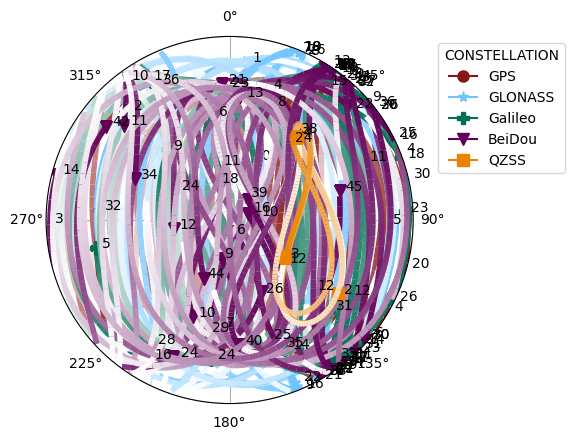

In [31]:
plot_gps(
    lat = 1.3521,
    lon = 103.8198,
    alt = 0,
    timestamp_start = datetime(2025, 3, 20, tzinfo=ZoneInfo("Asia/Singapore")),
    timestamp_end = datetime(2025, 3, 21, tzinfo=ZoneInfo("Asia/Singapore")))
print("Singapore on March 20, 2025")

ephemeris dates needed: [datetime.date(2021, 7, 22), datetime.date(2021, 7, 23)]
using previously downloaded file:
 /content/data/ephemeris/sp3/COD0MGXFIN_20212030000_01D_05M_ORB.SP3
using previously downloaded file:
 /content/data/ephemeris/sp3/COD0MGXFIN_20212040000_01D_05M_ORB.SP3
using previously downloaded file:
 /content/data/ephemeris/sp3/COD0MGXFIN_20212030000_01D_05M_ORB.SP3
using previously downloaded file:
 /content/data/ephemeris/sp3/COD0MGXFIN_20212040000_01D_05M_ORB.SP3
Tokyo on July 23, 2021


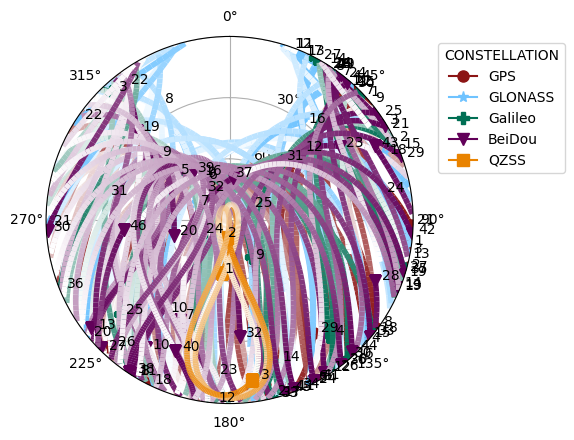

In [32]:
plot_gps(
    lat = 35.6764,
    lon = 139.6500,
    alt = 0,
    timestamp_start = datetime(2021, 7, 23, tzinfo=ZoneInfo("Asia/Tokyo")),
    timestamp_end = datetime(2021, 7, 24, tzinfo=ZoneInfo("Asia/Tokyo")))
print("Tokyo on July 23, 2021")

ephemeris dates needed: [datetime.date(2016, 8, 5), datetime.date(2016, 8, 6)]
using previously downloaded file:
 /content/data/ephemeris/sp3/com19085.sp3
using previously downloaded file:
 /content/data/ephemeris/sp3/com19086.sp3
using previously downloaded file:
 /content/data/ephemeris/sp3/com19085.sp3
using previously downloaded file:
 /content/data/ephemeris/sp3/com19086.sp3
Rio de Janeiro on August 5, 2016


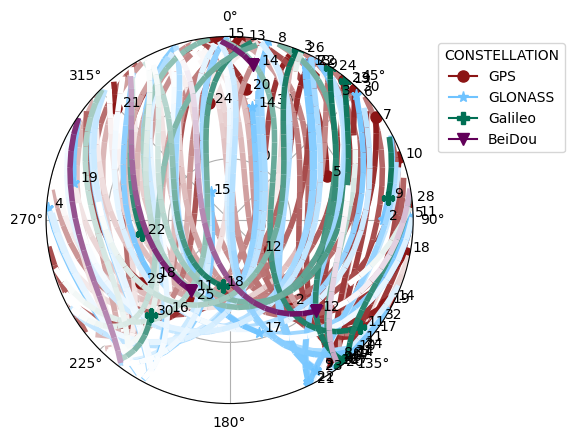

In [33]:
plot_gps(
    lat = -22.9068,
    lon = -43.1729,
    alt = 0,
    timestamp_start = datetime(2016, 8, 5, tzinfo=ZoneInfo("Brazil/East")),
    timestamp_end = datetime(2016, 8, 6, tzinfo=ZoneInfo("Brazil/East")))
print("Rio de Janeiro on August 5, 2016")